In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Setup

**Libraries imported:**

- `numpy` — numerical operations
- `pandas` — data manipulation
- `matplotlib.pyplot` — base plotting
- `seaborn` — statistical visualizations


In [37]:
df = pd.read_csv('titanic_data_updated.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## Dataset

Loads the **Titanic dataset** into a pandas DataFrame.
Contains passenger info: survival status, class, age, sex, fare.


## Multivariate Analysis


### 2.2 & 2.3 Multivariate Analysis- 1 ( Countplot with Hue )


<Axes: xlabel='Sex', ylabel='count'>

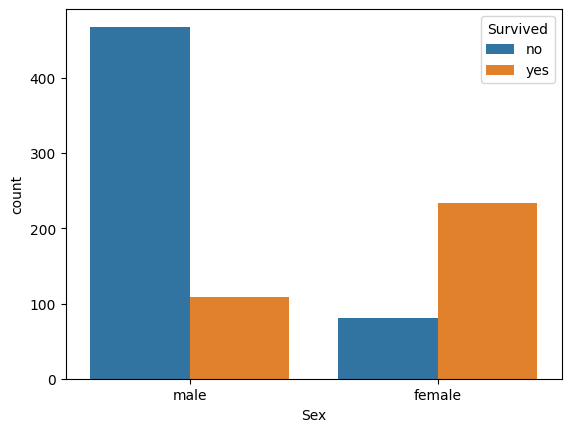

In [38]:
sns.countplot(x=df['Sex'],hue=df['Survived'])

### Note — Countplot: Sex vs Survived

- Plots count of male/female passengers split by survival (`hue`).
- ~74% of **females** survived vs only ~19% of **males**.
- Confirms the _women and children first_ evacuation policy.


In [39]:
gender_split = df.groupby('Sex')['Survived'].value_counts(normalize=True)
print(gender_split)

Sex     Survived
female  yes         0.742038
        no          0.257962
male    no          0.811092
        yes         0.188908
Name: proportion, dtype: float64


### Note — Normalized Survival by Gender

- `female/yes ≈ 0.74` → 74% of females survived
- `male/no ≈ 0.81` → 81% of males did NOT survive
- Backs up the countplot with exact percentages.


<Axes: xlabel='Pclass', ylabel='count'>

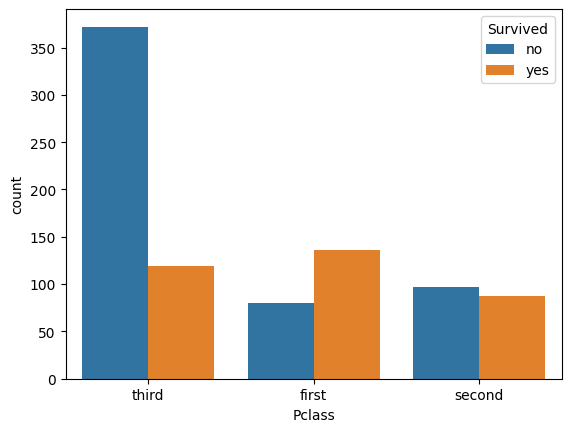

In [40]:
sns.countplot(x=df['Pclass'],hue=df['Survived'])

### Note — Countplot: Passenger Class vs Survived

- **1st class:** ~63% survived
- **2nd class:** ~47% survived
- **3rd class:** only ~24% survived
- Strong socioeconomic bias in survival rates.


In [41]:
pclass_split = df.groupby('Pclass')['Survived'].value_counts(normalize=True)

print(pclass_split)

Pclass  Survived
first   yes         0.629630
        no          0.370370
second  no          0.527174
        yes         0.472826
third   no          0.757637
        yes         0.242363
Name: proportion, dtype: float64


### Note — Normalized Survival by Passenger Class

Quantifies survival rate per class numerically, confirming the visual pattern.


### 2.4 Multi Variate Analysis -3 ( Barplot for Cat-Num)


<Axes: xlabel='Pclass', ylabel='Fare'>

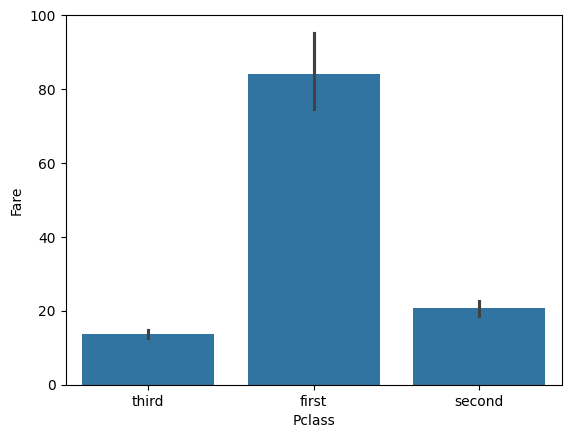

In [42]:
sns.barplot(x=df['Pclass'],y=df['Fare'])

### Note — Barplot: Passenger Class vs Mean Fare

- Shows **mean fare** per class with 95% confidence intervals.
- 1st class paid significantly higher fares — validates economic stratification.


<Axes: xlabel='Survived', ylabel='Age'>

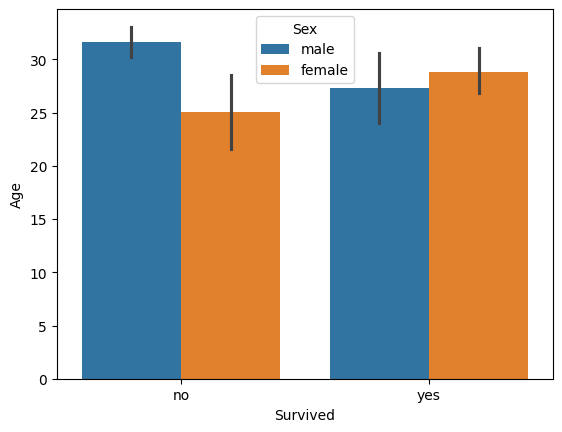

In [43]:
sns.barplot(x=df['Survived'],y=df['Age'],hue=df['Sex'])

### Note — Barplot: Survival vs Mean Age (by Gender)

- Compares mean age of survivors vs non-survivors broken down by gender.
- `hue='Sex'` reveals gender-specific age patterns within each survival group.


<Axes: xlabel='Survived', ylabel='Age'>

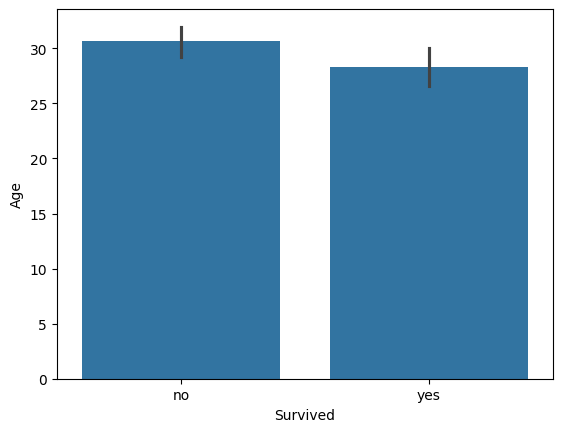

In [44]:
sns.barplot(x=df['Survived'],y=df['Age'])

### Note — Barplot: Survival vs Mean Age (Overall)

- Overall mean age of survivors vs non-survivors without gender breakdown.
- Survivors tend to be slightly younger on average.


### 2.6 Multivariate Analysis -4 ( KDE plot for categorical discrepancy )


<Axes: xlabel='Age', ylabel='Density'>

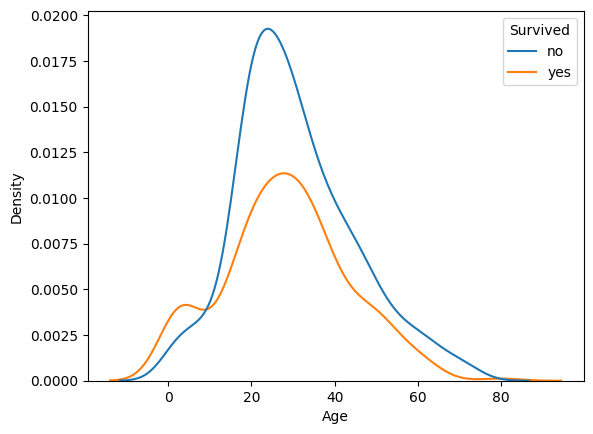

In [45]:
sns.kdeplot(data =df , x ='Age', hue='Survived')

### Note — KDE Plot: Age Distribution by Survival

- Plots **probability density** of age for survivors vs non-survivors.
- Children (age < 10) had higher survival rates.
- Middle-aged adults (20–40) show higher non-survival density.
- KDE reveals full distribution shape, not just the mean.


### 2.7 Multivariate Analysis -5 (Scatterplot)


In [46]:
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


### Note — Tips Dataset

Loads the built-in `tips` dataset (244 restaurant bills).
Columns: `total_bill`, `tip`, `sex`, `smoker`, `day`, `time`, `size`.
Used to demonstrate scatterplot with multiple encodings.


<Axes: xlabel='total_bill', ylabel='tip'>

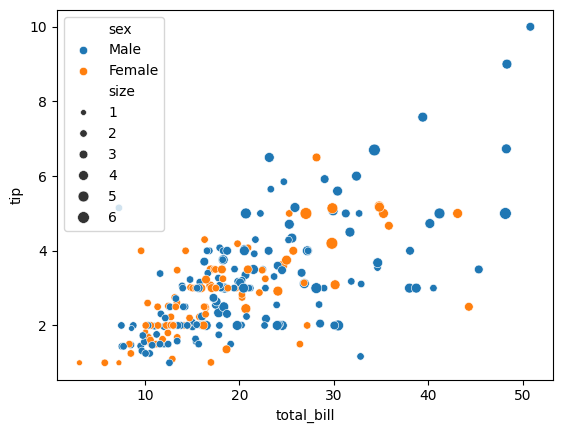

In [47]:
sns.scatterplot(data = df ,
                x='total_bill',
                y='tip',
                hue='sex',
                size='size')

### Note — Scatterplot: Total Bill vs Tip

- **Color (`hue`)** encodes customer gender
- **Point size (`size`)** encodes party size
- Positive correlation between bill amount and tip.
- Ideal for **Num × Num × Cat** relationships.


### 2.8 Y Data Profiling


In [51]:
# !pip install ydata_profiling


In [49]:
from ydata_profiling import ProfileReport


profile = ProfileReport(df ,title='Titanic Profile Report')

profile.to_file('my_report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:00<00:00, 3930.41it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]